In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [3]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [4]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_track.txt', sep='\\s+')
df2 = pd.read_csv('./xschem/simulation/tb_boot_bottom.txt', sep='\\s+')
df1

,time,v(vi),v(vc)
0,1.100000e-09,0.322019,0.321802
1,3.100000e-09,0.361584,0.361366
2,5.100000e-09,0.398627,0.398422
3,7.100000e-09,0.431632,0.431450
4,9.100000e-09,0.459248,0.459098
...,...,...,...
535,6.310000e-08,0.499160,0.499343
536,6.510000e-08,0.100154,0.100297
537,6.710000e-08,0.498463,0.497914
538,6.910000e-08,0.104944,0.105692


In [5]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [6]:
vi_track = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo_track = np.reshape(df1['v(vc)'].values, [runs, len(df1)//runs])
vi = np.reshape(df2['v(vi)'].values, [runs, len(df2)//runs])
vo = np.reshape(df2['v(vo)'].values, [runs, len(df2)//runs])

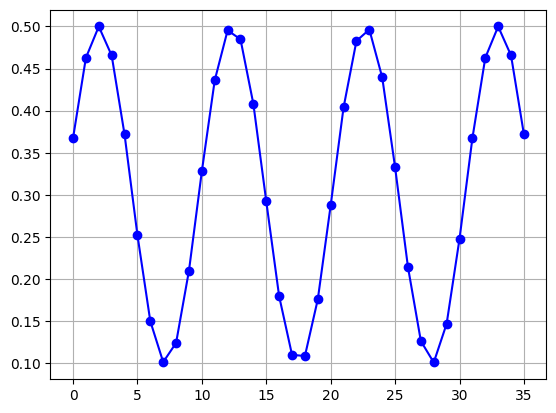

In [7]:
plt.plot(vo[2, :], "b-o")
plt.grid()
plt.show()

In [8]:
hd3_vi_track = compute_spectra(bins, vi_track, ndft)[1]
hd3_vo_track = compute_spectra(bins, vo_track, ndft)[1]
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

-1.3900740773524185e-09
-1.4050487408829446e-09
4.070155922998319e-09
2.2664249207253953e-09
2.3477768218101456e-09
1.7244877128681642e-09
9.095884576093406e-10
3.03276000650832e-09
1.2194213054565249e-08
6.569013853792818e-10
-6.003649183014227e-10
-8.783638478234871e-09
-6.305931194385796e-09
-5.3340402261914084e-08
2.382224916605105e-08
-1.3906600985560992e-09
2.0074953575676803e-09
1.9262786596665986e-09
2.8258696547407617e-09
2.8046999197165456e-09
-5.152213343902291e-09
0.0
7.126096541089905e-09
1.9743500691965832e-08
3.2953680474056785e-09
-6.002895026704813e-10
-1.1884201220452837e-08
-1.0308982802582882e-08
-8.898962160284488e-08
-1.1353708060813958e-08
-3.674924236764465e-08
5.400991932684175e-09
-1.6396344111708932e-07
-5.5923219694677526e-08
3.911276881054656e-08
8.688307026066026e-07
7.720928012543665e-07
3.8251900439874604e-08
2.04300345087049e-06
5.348505115133677e-07
-2.543178169913983e-07
1.3730624190583485e-06
8.663918181035477e-06
-4.264010672402657e-06
-9.6159298113

In [9]:
# Analytical data
vov = 0.734
vm = 0.20
fs = 500e6
fin = bins*fs/ndft
c = 1e-12
cb = 1e-12
cp =  100e-15
gds = 151e-3
fbw=1/(2*np.pi*c/gds)
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb+0.1)**2)
print(fbw/1e6)

24032.396406876196


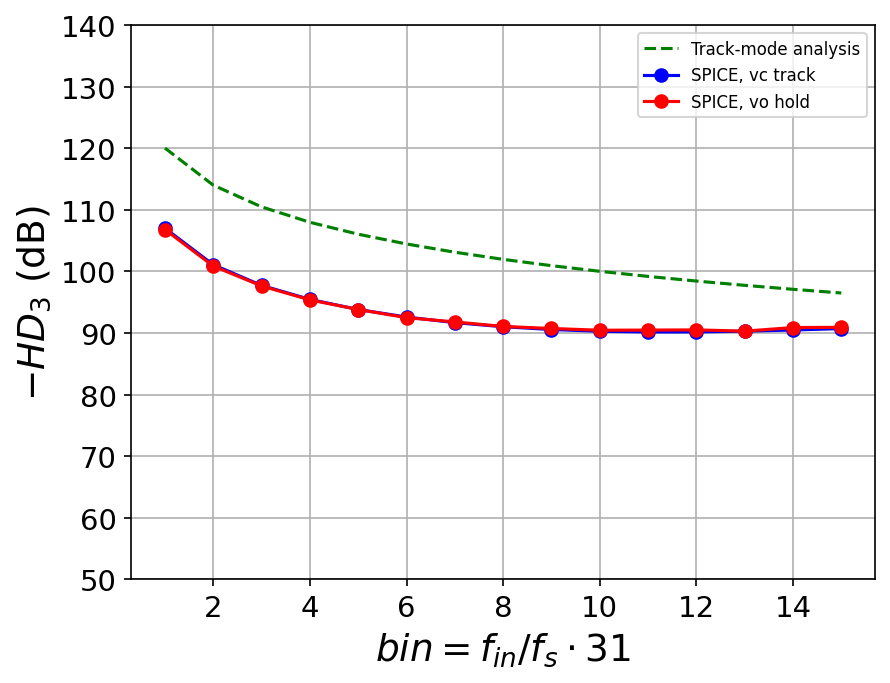

In [10]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Track-mode analysis')
#plt.plot(bins, hd3_vi_track, "b--", label='vi track')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo_track, "b-o", label='SPICE, vc track')
plt.plot(bins, hd3_vo, "r-o", label='SPICE, vo hold')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(50, 140)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

-1.2262467198136522e-07
1.76565371559914e-08
-6.830915269794443e-08
2.9575746854435183e-07
-1.3669470667295595e-06
-9.17405058746539e-07
-1.4755502786482918e-07
4.83068106587994e-07
9.96337031482849e-06
4.768464686646704e-09
4.187987670159545e-08
1.4175784524142007e-08
-1.529829252437112e-05
1.306832082641508e-06
7.893705653551955e-07


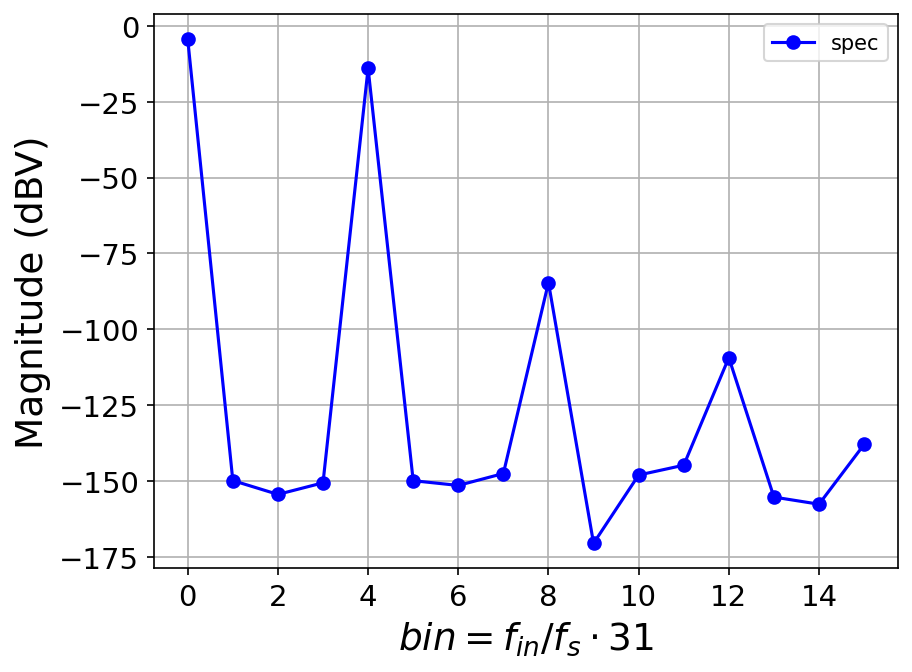

In [11]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o", label='spec')
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.legend()
plt.show()
